# Multi-Input Deep Learning — Design & Training

Tree ensembles reach ~0.94 AUC on the engineered features but that recall is the binding constraint — only ~9% of users are anomalous, so catching true positives matters more than raw accuracy.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             average_precision_score, roc_curve, precision_recall_curve,
                             precision_score, recall_score, f1_score)

In [3]:
pd.set_option('display.max_columns', 60)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
# ART_DIR = Path('../artifacts')
ART_DIR = Path('/content/drive/MyDrive/artifacts')
keras.utils.set_random_seed(42)
tf.__version__

'2.20.0'

## Load the engineered features

In [4]:
fe = pd.read_parquet(ART_DIR / 'cert_engineered_features.parquet')
fe.shape

(1000, 35)

In [5]:
y = fe['consensus_loose'].astype(int)
int(y.sum()), len(y)

(90, 1000)

## Feature branches
A multi-input design routes each semantic group of features through its own small sub-network before a late-fusion layer combines them. This lets each branch learn a representation appropriate to its scale and meaning rather than forcing one shared encoder over heterogeneous inputs. We use four branches drawn from the engineered matrix built in Notebook 04.

In [6]:
volume_features = [
    'total_logons', 'total_device_activities', 'total_file_activities', 'unique_files',
    'logon_intensity', 'device_intensity', 'file_intensity', 'activity_anomaly_score']

temporal_features = [
    'avg_logon_hour', 'std_logon_hour', 'avg_device_hour', 'avg_file_hour',
    'weekend_logons', 'after_hours_logons', 'after_hours_device', 'after_hours_files',
    'after_hours_logon_ratio', 'after_hours_device_ratio', 'after_hours_file_ratio',
    'weekend_logon_ratio']

access_features = ['unique_pcs_logon', 'unique_pcs_device', 'unique_pcs_file']

psych_features = ['O', 'C', 'E', 'A', 'N',
                  'risk_seeking', 'emotional_instability', 'conscientiousness_extraversion']

branches = {'volume': volume_features, 'temporal': temporal_features,
            'access': access_features, 'psych': psych_features}
{k: len(v) for k, v in branches.items()}

{'volume': 8, 'temporal': 12, 'access': 3, 'psych': 8}

**Two exclusions.** First, behavior_cluster is left out of every branch: it is a KMeans label computed from these same behavioural features, so feeding it back in would let the network shortcut through a hand-made summary of its own inputs rather than learning the structure directly. Second, the engineered matrix carries no iso_score/lof_score or consensus columns as inputs, so there is no leakage from the unsupervised detectors that generated the labels.

In [7]:
all_branch_features = sum(branches.values(), [])
missing = [f for f in all_branch_features if f not in fe.columns]
assert not missing, f'missing: {missing}'
len(all_branch_features)

31

## Train / validation / test split
Split before fitting any scaler. Stratifying on the label preserves the 9% anomaly rate in every partition.

In [8]:
idx = np.arange(len(fe))
idx_train, idx_tmp, y_train, y_tmp = train_test_split(
    idx, y, test_size=0.4, random_state=42, stratify=y)
idx_val, idx_test, y_val, y_test = train_test_split(
    idx_tmp, y_tmp, test_size=0.5, random_state=42, stratify=y_tmp)
len(idx_train), len(idx_val), len(idx_test)

(600, 200, 200)

In [9]:
int(y_train.sum()), int(y_val.sum()), int(y_test.sum())

(54, 18, 18)

Each branch is standardised with its own scaler, fitted on the training rows only. Keeping scalers separate mirrors the branch structure.

In [10]:
scalers = {}
def make_inputs(row_idx, fit=False):
    out = []
    for name, feats in branches.items():
        block = fe.loc[row_idx, feats].fillna(0).values.astype('float32')
        if fit:
            scalers[name] = StandardScaler().fit(block)
        out.append(scalers[name].transform(block).astype('float32'))
    return out

X_train = make_inputs(idx_train, fit=True)
X_val = make_inputs(idx_val)
X_test = make_inputs(idx_test)
[b.shape for b in X_train]

[(600, 8), (600, 12), (600, 3), (600, 8)]

## Focal loss
With positives so rare, plain binary cross-entropy is dominated by the easy majority class. Focal loss down-weights well-classified examples by a factor (1 - p_t)**gamma and applies an alpha weight to the positive class, concentrating gradient on the hard, rare anomalies.

In [11]:
def focal_loss(alpha=0.75, gamma=2.0):
    def loss(y_true, y_pred):
        eps = keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, eps, 1.0 - eps)
        y_true = tf.cast(y_true, y_pred.dtype)
        p_t = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
        a_t = tf.where(tf.equal(y_true, 1), alpha, 1 - alpha)
        return tf.reduce_mean(-a_t * tf.pow(1 - p_t, gamma) * tf.math.log(p_t))
    return loss

## Model architecture
Each branch is a two-layer encoder with batch-norm and dropout; the encoded branches are concatenated and passed through a shared fusion head to a single sigmoid output.

One classification head only.

In [12]:
def build_model(branches, feature_dims):
    inputs, encoded = [], []
    for name in branches:
        d = feature_dims[name]
        inp = layers.Input(shape=(d,), name=f'{name}_in')
        x = layers.Dense(max(16, 2 * d), activation='relu')(inp)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(max(8, d), activation='relu')(x)
        inputs.append(inp)
        encoded.append(x)
    merged = layers.Concatenate()(encoded)
    h = layers.Dense(48, activation='relu')(merged)
    h = layers.BatchNormalization()(h)
    h = layers.Dropout(0.4)(h)
    h = layers.Dense(24, activation='relu')(h)
    h = layers.Dropout(0.3)(h)
    out = layers.Dense(1, activation='sigmoid', name='anomaly')(h)
    return keras.Model(inputs=inputs, outputs=out)

feature_dims = {k: len(v) for k, v in branches.items()}
model = build_model(branches, feature_dims)
model.count_params()

4829

In [13]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ volume_in           │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_in         │ (None, 12)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ access_in           │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ psych_in            │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │        144 │ volume_in[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 24)        │        312 │ temporal_in[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 16)        │         64 │ access_in[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 16)        │        144 │ psych_in[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 16)        │         64 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24)        │         96 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16)        │         64 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16)        │         64 │ dense_6[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 24)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 16)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 16)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 8)         │        136 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 12)        │        300 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 8)         │        136 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 8)         │        136 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 36)        │          0 │ dense_1[0][0],  

 Total params: 4,829 (18.86 KB)

 Trainable params: 4,589 (17.93 KB)

 Non-trainable params: 240 (960.00 B)

## Compilation
Compile with focal loss and track both AUC and PR-AUC — the latter is the metric that actually reflects performance on the rare class. Because focal loss already re-weights the positive class through alpha, No need to additionally pass class_weight, which would double-count the imbalance correction.

In [14]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=focal_loss(alpha=0.75, gamma=2.0),
    metrics=[keras.metrics.AUC(name='auc'),
             keras.metrics.AUC(name='pr_auc', curve='PR')])

## Training

In [16]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_pr_auc', mode='max',
                                  patience=20, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                      patience=8, min_lr=1e-4)]

history = model.fit(
    X_train, y_train.values,
    validation_data=(X_val, y_val.values),
    epochs=150, batch_size=32, callbacks=callbacks, verbose=1)

history

Epoch 1/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - auc: 0.9204 - loss: 0.0231 - pr_auc: 0.5260 - val_auc: 0.9454 - val_loss: 0.0183 - val_pr_auc: 0.7245 - learning_rate: 1.0000e-04
Epoch 2/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - auc: 0.9208 - loss: 0.0221 - pr_auc: 0.4868 - val_auc: 0.9463 - val_loss: 0.0183 - val_pr_auc: 0.7270 - learning_rate: 1.0000e-04
Epoch 3/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - auc: 0.9229 - loss: 0.0223 - pr_auc: 0.5180 - val_auc: 0.9454 - val_loss: 0.0184 - val_pr_auc: 0.7239 - learning_rate: 1.0000e-04
Epoch 4/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - auc: 0.9266 - loss: 0.0221 - pr_auc: 0.5656 - val_auc: 0.9458 - val_loss: 0.0184 - val_pr_auc: 0.7251 - learning_rate: 1.0000e-04
Epoch 5/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - auc: 0.9284 - loss: 0.0209 - pr_auc: 0.6260 - val_auc: 0.9457 - val_loss: 0.0184 - val_pr_auc: 0.7265 - learning_rate: 1.0000e-04
Epoch 6/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - auc: 0.9342 - loss: 0.0212

## Training history

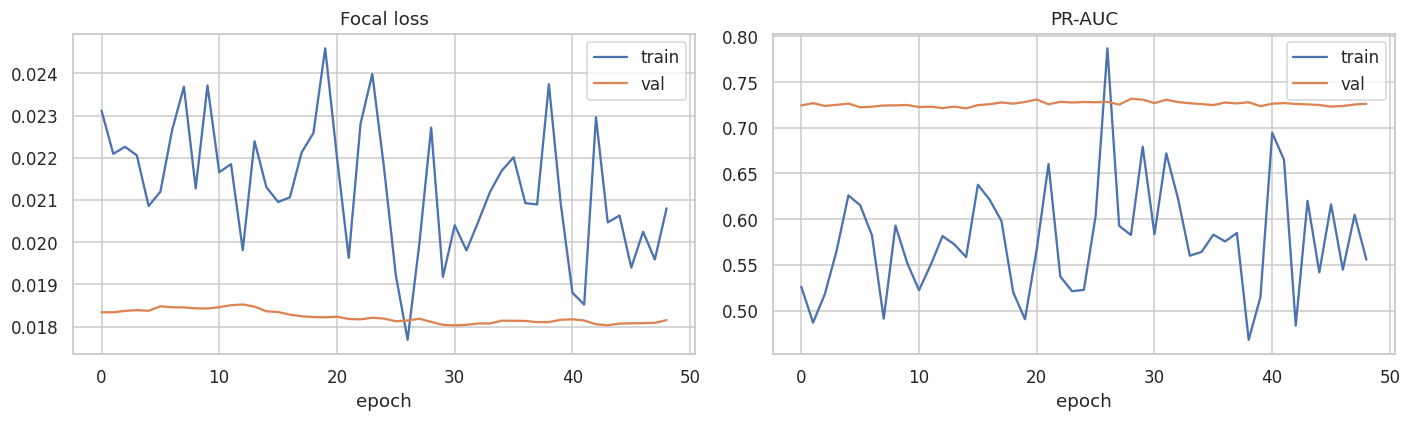

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Focal loss'); axes[0].set_xlabel('epoch'); axes[0].legend()
axes[1].plot(history.history['pr_auc'], label='train')
axes[1].plot(history.history['val_pr_auc'], label='val')
axes[1].set_title('PR-AUC'); axes[1].set_xlabel('epoch'); axes[1].legend()
plt.tight_layout()
plt.show()

## Test evaluation

In [18]:
proba = model.predict(X_test, verbose=0).ravel()
pred = (proba > 0.5).astype(int)
print(classification_report(y_test, pred, digits=3))

              precision    recall  f1-score   support

           0      0.972     0.962     0.967       182
           1      0.650     0.722     0.684        18

    accuracy                          0.940       200
   macro avg      0.811     0.842     0.826       200
weighted avg      0.943     0.940     0.941       200



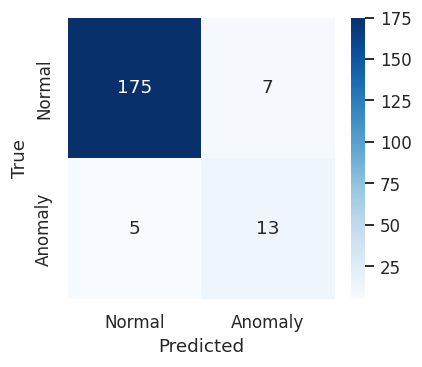

In [19]:
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(4, 3.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
plt.ylabel('True'); plt.xlabel('Predicted'); plt.tight_layout(); plt.show()

In [20]:
nn_roc = roc_auc_score(y_test, proba)
nn_pr = average_precision_score(y_test, proba)
round(nn_roc, 3), round(nn_pr, 3)

(np.float64(0.912), np.float64(0.602))

## ROC and precision–recall curves

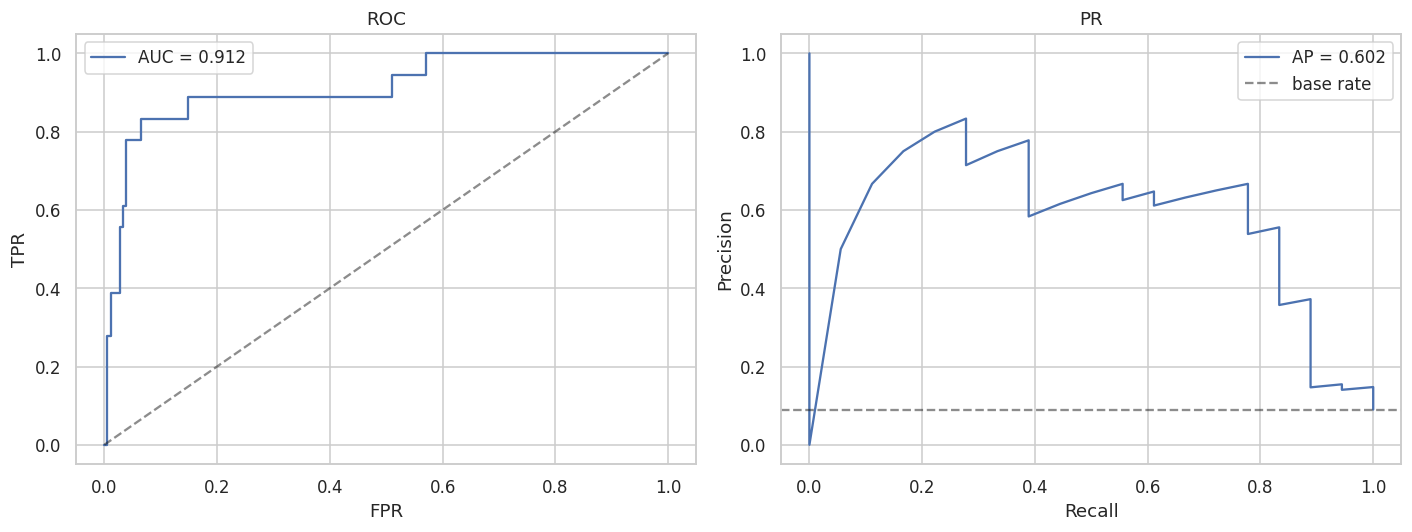

In [21]:
fpr, tpr, _ = roc_curve(y_test, proba)
prec, rec, _ = precision_recall_curve(y_test, proba)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr, tpr, label=f'AUC = {nn_roc:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].set_title('ROC'); axes[0].legend()
axes[1].plot(rec, prec, label=f'AP = {nn_pr:.3f}')
axes[1].axhline(y_test.mean(), color='k', ls='--', alpha=0.5, label='base rate')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].set_title('PR'); axes[1].legend()
plt.tight_layout()
plt.show()

The ROC curve sits clearly above the diagonal, but the PR curve — anchored to a 9% base rate

## Threshold sweep
Because false negatives (a missed insider) cost far more than false positives (an extra review) in this setting, the default 0.5 cut is rarely optimal. We sweep thresholds and select the one maximising F1 as a balanced reference point.

In [22]:
ths = np.linspace(0.05, 0.95, 91)
rows = []
for t in ths:
    p = (proba > t).astype(int)
    if p.sum() == 0:
        continue
    rows.append((t, precision_score(y_test, p, zero_division=0),
                 recall_score(y_test, p), f1_score(y_test, p)))
sweep = pd.DataFrame(rows, columns=['threshold', 'precision', 'recall', 'f1'])
best_t = sweep.loc[sweep['f1'].idxmax(), 'threshold']
best_t

np.float64(0.48999999999999994)

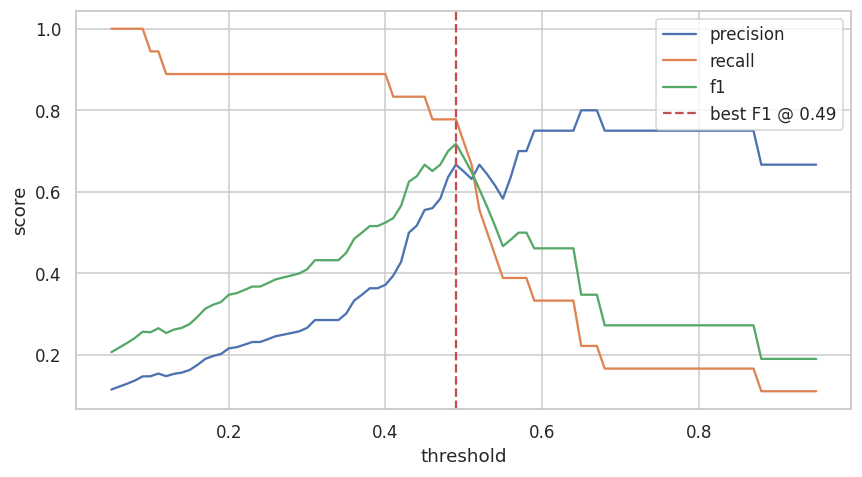

In [23]:
plt.figure(figsize=(8, 4.5))
for c in ['precision', 'recall', 'f1']:
    plt.plot(sweep['threshold'], sweep[c], label=c)
plt.axvline(best_t, color='r', ls='--', label=f'best F1 @ {best_t:.2f}')
plt.xlabel('threshold'); plt.ylabel('score'); plt.legend(); plt.tight_layout(); plt.show()

In [24]:
pred_best = (proba > best_t).astype(int)
print(classification_report(y_test, pred_best, digits=3))

              precision    recall  f1-score   support

           0      0.978     0.962     0.970       182
           1      0.667     0.778     0.718        18

    accuracy                          0.945       200
   macro avg      0.822     0.870     0.844       200
weighted avg      0.950     0.945     0.947       200



## Baseline comparison
To judge whether the branched network earns its complexity, we compare against the same tree and linear baselines, trained on the concatenated scaled branches.

In [25]:
Xtr = np.concatenate(X_train, axis=1)
Xte = np.concatenate(X_test, axis=1)

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(Xtr, y_train)
rf_proba = rf.predict_proba(Xte)[:, 1]

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(Xtr, y_train)
lr_proba = lr.predict_proba(Xte)[:, 1]

compare = pd.DataFrame({
    'roc_auc': [roc_auc_score(y_test, m) for m in [proba, rf_proba, lr_proba]],
    'pr_auc': [average_precision_score(y_test, m) for m in [proba, rf_proba, lr_proba]],
}, index=['Multi-input NN', 'Random Forest', 'Logistic Regression']).round(3)
compare

,roc_auc,pr_auc
Multi-input NN,0.912,0.602
Random Forest,0.911,0.724
Logistic Regression,0.851,0.615


In [26]:
model.save(ART_DIR / 'dl_multiinput_model.keras')
joblib.dump(scalers, ART_DIR / 'dl_branch_scalers.joblib')
json.dump(branches, open(ART_DIR / 'dl_branch_manifest.json', 'w'), indent=2)
np.savez(ART_DIR / 'dl_split_indices.npz',
         train=idx_train, val=idx_val, test=idx_test)
sorted(p.name for p in ART_DIR.glob('dl_*'))

['dl_branch_manifest.json',
 'dl_branch_scalers.joblib',
 'dl_multiinput_model.keras',
 'dl_split_indices.npz']